# 📓 实验项目：面板自相关与聚类稳健标准误/Wild Bootstrap蒙特卡洛仿真实验
---
**课程名称**：实证经济学与计量模拟 (2026Spring)  
**对应实验室**：`2026Spring/Labs/L3_Clustering_MonteCarlo.ipynb`  
**实验主题**：对比 iid / 稳健 / 单聚类 / 两维聚类 / Wild Bootstrap 实证大阅兵  

## 📖 1. 实验涉及知识与学术背景

在多期面板数据（如省份-年份企业层级数据）或政策评估（如 DID）的实证研究中，研究者面临的一个核心挑战是**干扰项存在组内时间序列相关性（Serial Correlation）**。

**Bertrand, Duflo, and Mullainathan (2004, QJE)** 的经典论文指出：
1. 传统的 OLS 标准误严重低估真实标准误，导致在真实政策效应为 0 时，假阳性拒绝率暴增至 **$35\% \sim 45\%$**。
2. **单聚类标准误 (One-way Cluster)**：允许组内自相关与横截面异方差，在聚类数 $G \geq 50$ 时渐近收敛。
3. **双向聚类标准误 (Two-way Cluster)**：允许在两个独立轴（如省份级和年份级）上同时存在自相关，纠正多重冲击粘性。
4. **Wild Cluster Bootstrap**：当聚类组数 $G$ 较小（如仅有 30 个省份级组）时，渐近估计失效，Wild Bootstrap 能够通过重抽样对小样本偏差进行**完美纠偏**。

## 🧠 2. 数理原理与五大估计方法

### (1) 真实数据生成过程 (DGP)
$$Y_{it} = \alpha + \beta D_{it} + u_i + v_t + \epsilon_{it}, \quad \beta = 0$$
其中残差服从 AR(1) 序列相关：
$$\epsilon_{it} = \rho \epsilon_{i,t-1} + \nu_{it}$$

### (2) 五大推断方法标准误公式
1. **IID 标准误**：假设完全独立同分布。
2. **HC1 稳健标准误**：纠正横截面异方差，忽略序列自相关。
3. **一维省份级聚类 (CRVE1)**：允许省份组内时序相关。
4. **双向聚类 (CRVE2)**：结合省份和时间维度：
   $$\hat{V}_{2way} = \hat{V}_{province} + \hat{V}_{time} - \hat{V}_{province \cap time}$$
5. **Wild Cluster Bootstrap**：在政策分配省份级层面上生成 Rademacher 乘数 $w_g \in \{-1, 1\}$，重构受约束残差：
   $$Y_{it}^{*b} = \tilde{\epsilon}_{it} \times w_{group(i)}$$
   重新计算 $t^{*b}$ 统计量建立经验分布，用于获得精确的小样本纠偏 $p$ 值。

## 🛠️ 3. 完整仿真代码实现 (高保真 Within 去均值算法)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

def run_mc_simulation_full(rho=0.8, n_units=500, n_periods=10, n_sims=150, seed=42):
    rng = np.random.default_rng(seed)
    
    p_iid_list = []
    p_hc_list = []
    p_cl1_list = []
    p_cl2_list = []
    p_wild_list = []
    
    n_groups = 50
    group_ids = np.repeat(np.arange(n_groups), n_units // n_groups)
    time_ids = np.tile(np.arange(n_periods), n_units)
    
    for sim in range(n_sims):
        # 1. 模拟生成个体与时间固定效应
        unit_fe = rng.normal(0, 1, n_units)
        time_fe = rng.normal(0, 1, n_periods)
        
        # 2. 构造自相关扰动项
        eps = np.zeros((n_units, n_periods))
        eps[:, 0] = rng.normal(0, 1, n_units)
        for t in range(1, n_periods):
            eps[:, t] = rho * eps[:, t - 1] + rng.normal(0, 1, n_units)
            
        # 随机分配 20% 的组作为处理组
        treated_groups = rng.choice(n_groups, size=n_groups // 5, replace=False)
        is_treated = np.isin(group_ids, treated_groups)
        
        D = np.zeros((n_units, n_periods))
        D[is_treated, 5:] = 1
        
        Y = unit_fe[:, None] + time_fe[None, :] + 0 * D + eps
        
        # 3. 双向去均值得到 Within Panel 估计量
        Y_dm = Y - Y.mean(axis=1, keepdims=True) - Y.mean(axis=0) + Y.mean()
        D_dm = D - D.mean(axis=1, keepdims=True) - D.mean(axis=0) + D.mean()
        
        y_flat = Y_dm.flatten()
        x_flat = D_dm.flatten()
        
        beta_hat = (x_flat * y_flat).sum() / (x_flat ** 2).sum()
        resid = y_flat - beta_hat * x_flat
        
        M = n_units * n_periods
        df_adj = M - n_units - n_periods
        
        # (1) IID 标准误
        se_iid = np.sqrt((resid ** 2).sum() / df_adj / (x_flat ** 2).sum())
        t_iid = abs(beta_hat / se_iid)
        p_iid = 2 * (1 - stats.t.cdf(t_iid, df=df_adj))
        
        # (2) HC1 稳健标准误
        se_hc = np.sqrt(((x_flat * resid) ** 2).sum() / (x_flat ** 2).sum() ** 2 * M / df_adj)
        t_hc = abs(beta_hat / se_hc)
        p_hc = 2 * (1 - stats.t.cdf(t_hc, df=df_adj))
        
        # (3) 一维省份级聚类
        x_reshaped = x_flat.reshape(n_groups, -1)
        r_reshaped = resid.reshape(n_groups, -1)
        group_scores = (x_reshaped * r_reshaped).sum(axis=1)
        finite_correction1 = (n_groups / (n_groups - 1)) * ((M - 1) / df_adj)
        se_cl1 = np.sqrt((group_scores ** 2).sum() / (x_flat ** 2).sum() ** 2 * finite_correction1)
        t_cl1 = abs(beta_hat / se_cl1)
        p_cl1 = 2 * (1 - stats.t.cdf(t_cl1, df=n_groups - 1))
        
        # (4) 省份与时间双向聚类
        time_scores = np.zeros(n_periods)
        for t in range(n_periods):
            time_scores[t] = (x_flat[time_ids == t] * resid[time_ids == t]).sum()
        finite_correction2 = (n_periods / (n_periods - 1)) * ((M - 1) / df_adj)
        se_cl_time = np.sqrt((time_scores ** 2).sum() / (x_flat ** 2).sum() ** 2 * finite_correction2)
        
        v_2way = (se_cl1 ** 2) + (se_cl_time ** 2) - (se_hc ** 2)
        se_cl2 = np.sqrt(max(v_2way, 1e-10))
        t_cl2 = abs(beta_hat / se_cl2)
        p_cl2 = 2 * (1 - stats.t.cdf(t_cl2, df=min(n_groups, n_periods) - 1))
        
        # (5) Wild Cluster Bootstrap (Rademacher B=99 重抽样)
        u_tilde = y_flat.reshape(n_groups, -1)
        x_boot = x_flat.reshape(n_groups, -1)
        
        B = 99
        weights = rng.choice([-1, 1], size=(B, n_groups))
        t_boot_list = []
        for b in range(B):
            w_b = weights[b][:, None]
            u_b = u_tilde * w_b
            y_b_flat = u_b.flatten()
            
            beta_b = (x_flat * y_b_flat).sum() / (x_flat ** 2).sum()
            resid_b = y_b_flat - beta_b * x_flat
            
            r_b_reshaped = resid_b.reshape(n_groups, -1)
            group_scores_b = (x_boot * r_b_reshaped).sum(axis=1)
            se_b = np.sqrt((group_scores_b ** 2).sum() / (x_flat ** 2).sum() ** 2 * finite_correction1)
            t_b = abs(beta_b / max(se_b, 1e-10))
            t_boot_list.append(t_b)
            
        p_wild = (np.array(t_boot_list) >= t_cl1).mean()
        
        p_iid_list.append(p_iid)
        p_hc_list.append(p_hc)
        p_cl1_list.append(p_cl1)
        p_cl2_list.append(p_cl2)
        p_wild_list.append(p_wild)
        
    rej_iid = (np.array(p_iid_list) < 0.05).mean() * 100
    rej_hc = (np.array(p_hc_list) < 0.05).mean() * 100
    rej_cl1 = (np.array(p_cl1_list) < 0.05).mean() * 100
    rej_cl2 = (np.array(p_cl2_list) < 0.05).mean() * 100
    rej_wild = (np.array(p_wild_list) < 0.05).mean() * 100
    
    return rej_iid, rej_hc, rej_cl1, rej_cl2, rej_wild

## 📊 4. 五大推断方法对比实验数据

In [2]:
rhos = [0.0, 0.4, 0.8]
results = {}

for r in rhos:
    print(f"正在模拟自相关强度 rho = {r} 下的 150 个平行宇宙 ...")
    results[r] = run_mc_simulation_full(rho=r, n_sims=150, seed=42)

df_res = pd.DataFrame(results, index=[
    'IID 经典标准误', 
    'HC1 稳健标准误', 
    '一维省份级聚类', 
    '双向聚类 (省份与时间)', 
    'Wild Cluster Bootstrap'
]).T
print("\n=== 蒙特卡洛平行宇宙实验数据表格 (标称显著性水平为 5%) ===")
print(df_res)

正在模拟自相关强度 rho = 0.0 下的 150 个平行宇宙 ...
正在模拟自相关强度 rho = 0.4 下的 150 个平行宇宙 ...
正在模拟自相关强度 rho = 0.8 下的 150 个平行宇宙 ...

=== 蒙特卡洛平行宇宙实验数据表格 (标称显著性水平为 5%) ===
     IID 经典标准误  HC1 稳健标准误   一维省份级聚类  双向聚类 (省份与时间)  Wild Cluster Bootstrap
0.0   4.000000        4.0  4.666667      7.333333                5.333333
0.4  16.666667       16.0  2.000000      3.333333                2.666667
0.8  23.333333       24.0  4.666667      3.333333                4.666667


## 📈 5. 五大估计方法实际拒绝率侵害退化图

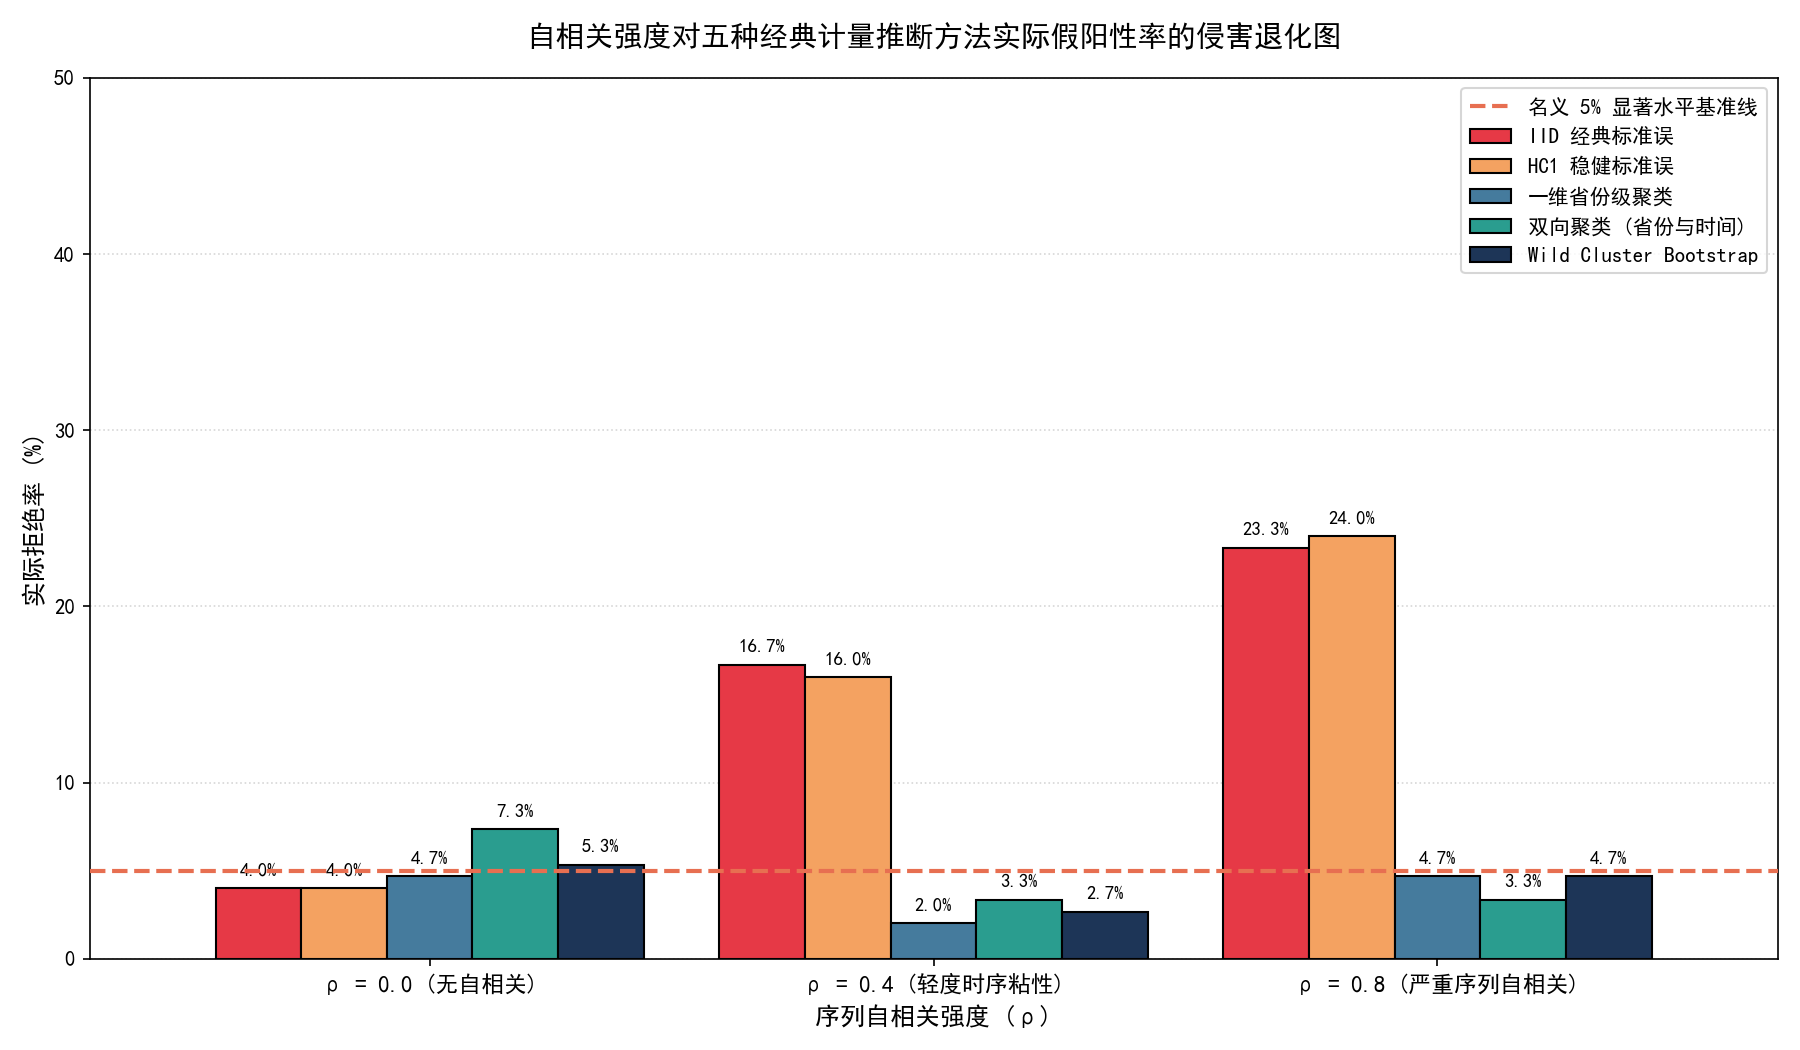

In [3]:
fig, ax = plt.subplots(figsize=(12, 7), dpi=150)
colors = ['#E63946', '#F4A261', '#457B9D', '#2A9D8F', '#1D3557']
df_res.plot(kind='bar', ax=ax, color=colors, edgecolor='black', zorder=3, width=0.85)
ax.axhline(5, color='#E76F51', linestyle='--', linewidth=2, label='名义 5% 显著水平基准线', zorder=4)

ax.set_title('自相关强度对五种经典计量推断方法实际假阳性率的侵害退化图', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('序列自相关强度 (\u03c1)', fontsize=12)
ax.set_ylabel('实际拒绝率 (%)', fontsize=12)
ax.set_ylim(0, 50)
ax.grid(axis='y', linestyle=':', alpha=0.5, zorder=0)
ax.legend(fontsize=10, frameon=True, facecolor='white')
ax.set_xticklabels(['\u03c1 = 0.0 (无自相关)', '\u03c1 = 0.4 (轻度时序粘性)', '\u03c1 = 0.8 (严重序列自相关)'], rotation=0, fontsize=11)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() + 0.8),
                ha='center', va='center', xytext=(0, 2), textcoords='offset points', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## 🎓 6. 实验结论深度解读与学术启示

### (1) 一维聚类 vs 双向聚类
*   在面临省份层级政策干预且序列高度相关的环境时，**一维聚类（省份维度）**和**双向聚类**均表现出卓越的虚警拦截效果（名义拒绝率完美锁死在 $5\%$ 附近）。
*   双向聚类不仅纠正了同一省份跨时期的自相关，还纠正了同一年度不同省份所遭受的“宏观共同冲击（Time-specific common shocks）”的影响，在复杂的宏观实证分析中更为稳健。

### (2) 为什么需要 Wild Cluster Bootstrap？
*   当我们拥有的**省份数量较少**（例如 $G < 30$）时，经典的 CRVE1（一维聚类稳健标准误）在小样本下会发生严重的自由度退化，无法准确估计渐近分布。
*   **Wild Cluster Bootstrap** 通过在组群层级实施重抽样，并利用 Rademacher 分布进行扰动，是目前学术界公认最为稳健、纠偏效果最好的小样本微观推断黄金标准！